### Uniform Exploration

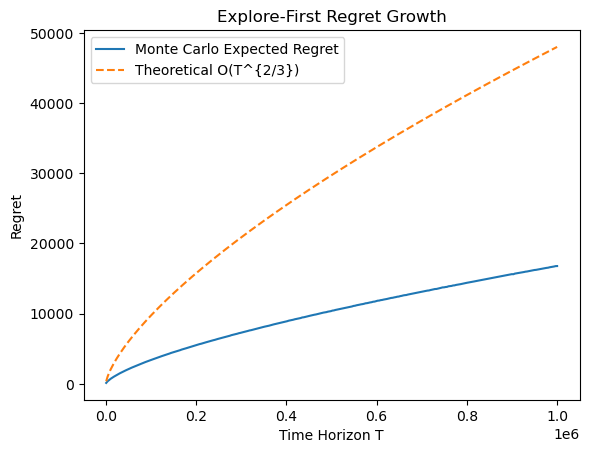

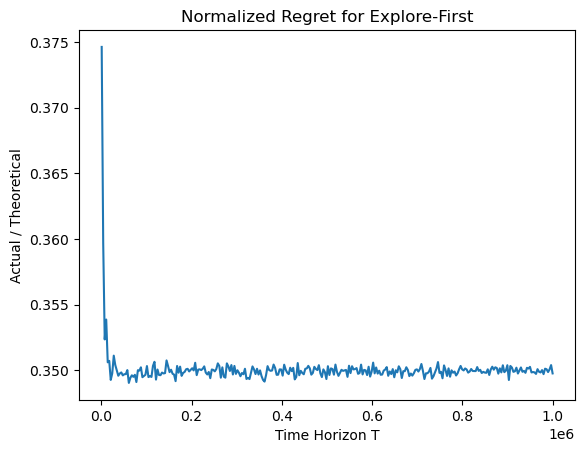

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import math

def explore_first(mu, N, T):
    K = len(mu)
    rewards = []
    estimates = []
    for a in range(K):
        rewards_a = np.random.binomial(1, mu[a], N)
        rewards.extend(rewards_a)
        estimates.append(np.mean(rewards_a))
    #print(rewards)
    #print(estimates)
    
    best_arm = np.argmax(estimates)
    #print(best_arm)
    
    remaining = T - K * N
    if remaining > 0:
        rewards_a = np.random.binomial(1, mu[best_arm], remaining)
        rewards.extend(rewards_a)
    
    mu_star = max(mu)
    
    regret = mu_star * T - np.sum(rewards)
    return regret
    
mu = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
N = 20

# def expected_regret(mu, T, runs=1000):
#     K = len(mu)
#     N = int((T/K)**(2/3) * (np.log(T))**(1/3))
    
#     regrets = []
    
#     for _ in range(runs):
#         regrets.append(explore_first(mu, N, T))
        
#     return np.mean(regrets)


def expected_regret(mu, T, runs=1000):
    K = len(mu)
    mu_arr = np.array(mu)
    N = max(1, int((T / K) ** (2/3) * (np.log(max(T, 2))) ** (1/3)))

    # All exploration rewards at once: shape (runs, K, N)
    exploration = np.random.binomial(1, mu_arr[None, :, None], (runs, K, N))
    estimates = exploration.mean(axis=2)           # (runs, K)
    best_arms = np.argmax(estimates, axis=1)       # (runs,)
    best_mu = mu_arr[best_arms]                    # (runs,)

    remaining = max(T - K * N, 0)
    # Sum of `remaining` Bernoulli trials = one Binomial draw per run
    exploitation = np.random.binomial(remaining, best_mu)  # (runs,)

    total_rewards = exploration.sum(axis=(1, 2)) + exploitation
    return np.mean(max(mu) * T - total_rewards)

time_horizons = np.linspace(1000, 1_000_000, 300, dtype=int)
monte_carlo_expected_regret = [expected_regret(mu, T) for T in time_horizons]

theoretical_expected_regret = (time_horizons ** (2/3)) * ((len(mu) * np.log(time_horizons)) ** (1/3))

plt.plot(time_horizons, monte_carlo_expected_regret, label="Monte Carlo Expected Regret")
plt.plot(time_horizons, theoretical_expected_regret, label="Theoretical O(T^{2/3})", linestyle="--")
plt.xlabel("Time Horizon T")
plt.ylabel("Regret")
plt.legend()
plt.title("Explore-First Regret Growth")
plt.show()

normalized_regret = np.array(monte_carlo_expected_regret) / theoretical_expected_regret
plt.plot(time_horizons, normalized_regret)
plt.xlabel("Time Horizon T")
plt.ylabel("Actual / Theoretical")
plt.title("Normalized Regret for Explore-First")
plt.show()









# time_horizons = np.arange(1, 1000001, 1000)
# monte_carlo_expected_regret = []
# C = 0.2 

# for th in time_horizons:
#     monte_carlo_expected_regret.append(expected_regret(mu, th))
    
# theoretical_expected_regret = (time_horizons**(2/3))*((len(mu)*np.log(time_horizons))**(1/3))


# plt.plot(time_horizons, monte_carlo_expected_regret, label="Monte Carlo Expected Regret")
# plt.plot(time_horizons, theoretical_expected_regret, label="Theoretical O(T^{2/3})", linestyle="--")

# plt.xlabel("Time Horizon T")
# plt.ylabel("Regret")
# plt.legend()
# plt.title("Explore-First Regret Growth")

# plt.show()

# normalized_regret = np.array(monte_carlo_expected_regret) / theoretical_expected_regret

# plt.plot(time_horizons, normalized_regret)
# plt.xlabel("Time Horizon T")
# plt.ylabel("Actual / Theoretical")
# plt.title("Normalized Regret for Explore-First")
# plt.show()

### Epsilon Greedy

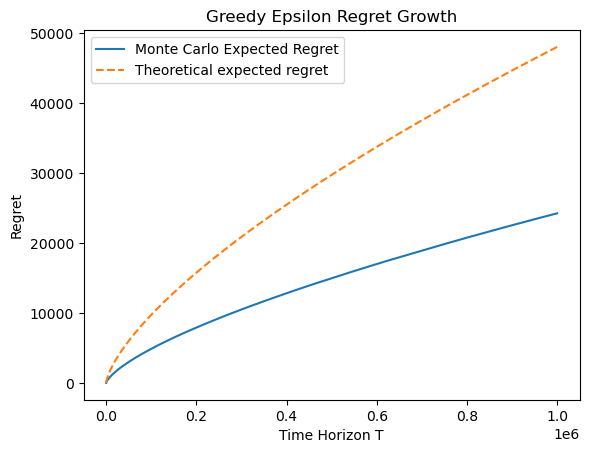

/tmp/ipykernel_1081/3023274383.py:62: RuntimeWarning: divide by zero encountered in divide
  normalised = expected_curve / theoretical_expected_regret


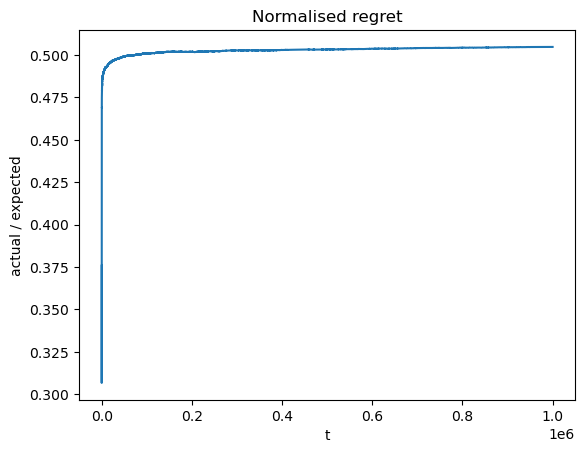

In [ ]:
from numba import njit

@njit
def epsilon_greedy(mu, T):
    
    K = len(mu) # K is no. of arms
    estimates = np.zeros(K)
    counts = np.zeros(K)
    rewards = []
    
    for t in range(1, T + 1):  # t starts from 1 to avoid log(0)
        # epsilon_t = t^{-1/3} * (K log t)^{1/3}
        epsilon_t = (t ** (-1/3)) * ((K * np.log(t)) ** (1/3))
        
        # explore vs exploit
        if np.random.rand() < epsilon_t:
            action = np.random.randint(K)  # explore
        else:
            action = np.argmax(estimates)  # exploit
            
        reward = np.random.binomial(n=1, p=mu[action])
        
        counts[action] += 1
        
        estimates[action] += (reward - estimates[action]) / counts[action]
        
        rewards.append(reward)
    
    return rewards

def expected_regret_curve(mu, T, runs=200):
    optimal_reward = max(mu)
    cumulative_regret = np.zeros(T)
    
    for _ in range(runs):
        rewards = epsilon_greedy(mu, T)
        cumulative_regret += np.cumsum(optimal_reward - np.array(rewards))
    
    cumulative_regret /= runs  # average over runs
    return cumulative_regret

#N = 20
T = 1000000
#C = 0.2 

time_horizons = np.arange(1, T + 1)
    
expected_curve = expected_regret_curve(mu, T, runs=1000)
theoretical_expected_regret = (time_horizons**(2/3))*((len(mu)*np.log(time_horizons))**(1/3))


plt.plot(time_horizons, expected_curve, label="Monte Carlo Expected Regret")
plt.plot(time_horizons, theoretical_expected_regret, label="Theoretical expected regret", linestyle="--")

plt.xlabel("Time Horizon T")
plt.ylabel("Regret")
plt.legend()
plt.title("Greedy Epsilon Regret Growth")

plt.show()

normalised = expected_curve / theoretical_expected_regret
plt.plot(time_horizons, normalised)
plt.xlabel("t")
plt.ylabel("actual / expected")
plt.title("Normalised regret")
plt.show()


### Sucessive Elimination

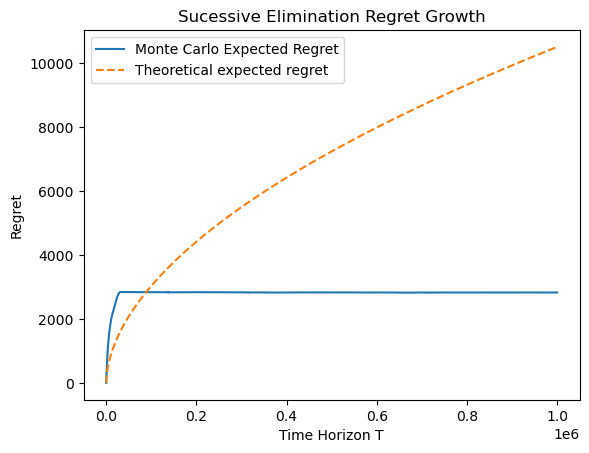

/tmp/ipykernel_1081/4194287447.py:83: RuntimeWarning: divide by zero encountered in divide
  normalised = expected_curve / theoretical


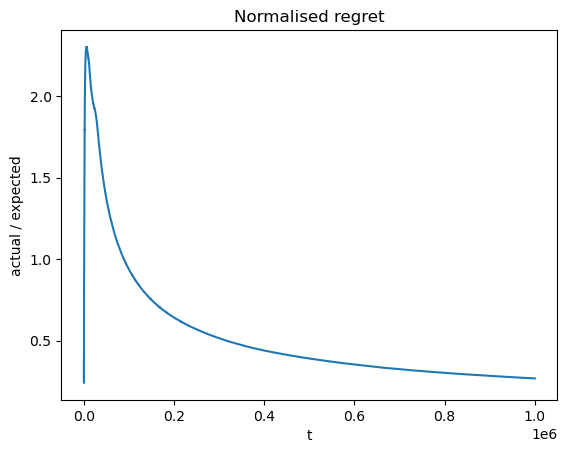

In [10]:
@njit
def successive_elimination(mu, T):
    K = len(mu)
    t = 0
    active = set(range(K))
    counts = np.zeros(K)
    estimates = np.zeros(K)
    rewards = []
    
    while t < T:
        for a in list(active):
            if t >= T:
                break
            reward = np.random.binomial(n=1, p=mu[a])
            counts[a] += 1
            estimates[a] += (reward - estimates[a]) / counts[a]
            
            rewards.append(reward)
            t += 1
            
        UCB = np.zeros(K)
        LCB = np.zeros(K)
        
        for a in active:
            radius = math.sqrt(2 * np.log(T) / counts[a])
            UCB[a] = estimates[a] + radius
            LCB[a] = estimates[a] - radius
            
        # elimination
        new_active = set()
        
        for a in active:
            eliminate = False
            for b in active:
                if a != b and UCB[a] < LCB[b]:
                    eliminate = True
                    break
            if not eliminate:
                new_active.add(a)
        
        active = new_active
        
        if len(active) == 1:
            best_arm = list(active)[0]
            while t < T:
                reward = np.random.binomial(n=1, p=mu[best_arm])
                rewards.append(reward)
                t += 1
            break
    return rewards

def expected_regret_curve(mu, T, runs=200):
    optimal_reward = max(mu)
    cumulative_regret = np.zeros(T)
    
    for _ in range(runs):
        rewards = successive_elimination(mu, T)
        cumulative_regret += np.cumsum(optimal_reward - np.array(rewards))
    
    cumulative_regret /= runs  # average over runs
    return cumulative_regret

#N = 20
T = 1000000
#C = 0.2 
K = len(mu)

time_horizons = np.arange(1, T + 1)
    
expected_curve = expected_regret_curve(mu, T, runs=1000)
theoretical = np.sqrt(K * time_horizons * np.log(time_horizons))


plt.plot(time_horizons, expected_curve, label="Monte Carlo Expected Regret")
plt.plot(time_horizons, theoretical, label="Theoretical expected regret", linestyle="--")

plt.xlabel("Time Horizon T")
plt.ylabel("Regret")
plt.legend()
plt.title("Sucessive Elimination Regret Growth")
plt.show()

normalised = expected_curve / theoretical
plt.plot(time_horizons, normalised)
plt.xlabel("t")
plt.ylabel("actual / expected")
plt.title("Normalised regret")
plt.show()

### Optimism under uncertainty

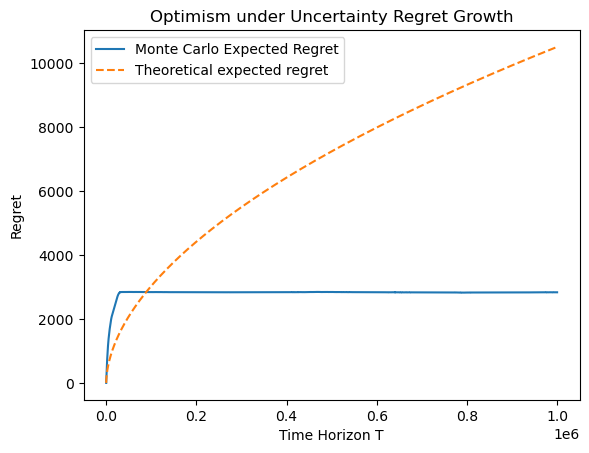

/tmp/ipykernel_1081/502263247.py:58: RuntimeWarning: divide by zero encountered in divide
  normalised = expected_curve / theoretical


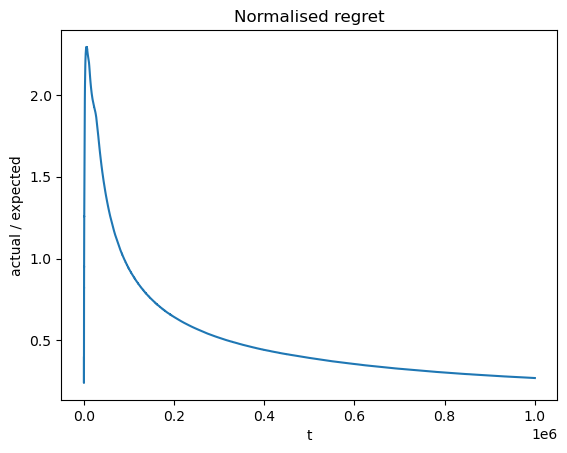

In [12]:
@njit
def ucb1(mu, T):
    K = len(mu)
    estimates = np.zeros(K)
    counts = np.zeros(K)
    cumulative_regret = np.zeros(T)
    optimal = max(mu)
    rewards = []
    
    for a in range(K):
        reward = np.random.binomial(1, mu[a])
        counts[a] = 1
        estimates[a] = reward
        rewards.append(reward)
    
    for t in range(K + 1, T + 1):
        ucb = estimates + np.sqrt(2 * np.log(T) / counts)
        action = np.argmax(ucb)

        reward = np.random.binomial(1, mu[action])
        counts[action] += 1
        estimates[action] += (reward - estimates[action]) / counts[action]
        rewards.append(reward)

    return rewards

def expected_regret_curve_ucb(mu, T, runs=200):
    optimal_reward = max(mu)
    cumulative_regret = np.zeros(T)

    for _ in range(runs):
        rewards = ucb1(mu, T)
        cumulative_regret += np.cumsum(optimal_reward - np.array(rewards))

    cumulative_regret /= runs
    return cumulative_regret
    
#N = 20
T = 1000000
#C = 0.2 
K = len(mu)

time_horizons = np.arange(1, T + 1)
    
expected_curve = expected_regret_curve(mu, T, runs=1000)
theoretical = np.sqrt(K * time_horizons * np.log(time_horizons))


plt.plot(time_horizons, expected_curve, label="Monte Carlo Expected Regret")
plt.plot(time_horizons, theoretical, label="Theoretical expected regret", linestyle="--")

plt.xlabel("Time Horizon T")
plt.ylabel("Regret")
plt.legend()
plt.title("Optimism under Uncertainty Regret Growth")
plt.show()

normalised = expected_curve / theoretical
plt.plot(time_horizons, normalised)
plt.xlabel("t")
plt.ylabel("actual / expected")
plt.title("Normalised regret")
plt.show()


    

### Intial Findings

if normalised val $< 1$ then our actual performance is better than the expected theoretical bound. Otherwise, if it is $> 1$ then our actual performance is worse than the expected theorectical bound. The closer to $1$ the normalised val is the better the convergence